# 04_semblance_analysis.ipynb

**Purpose:**  
- Deep‐dive into geophysical attributes per sample  
- Generate and compare semblance panels  
- Perform first‐break picking and time‐depth profiling  
- Explore coherence vs. velocity‐gradient relationships  
- Validate that these physics‐driven features add signal beyond our hand‐crafted stats


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import hilbert
from skimage.filters import sobel

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path: sys.path.insert(0, repo_root)

from src.loaders import get_training_ids, load_gather
from src.geophysical import compute_semblance_panel, compute_metrics, pick_first_breaks_per_shot

plt.style.use('ggplot')
sns.set_context('notebook')

In [2]:
# Our “final_features.csv” includes: hand‐crafted metrics + umap1/umap2 + split
df_feats = pd.read_csv('../data/processed/final_features.csv')
train_ids = df_feats[df_feats.split=='train']['sample_id'].tolist()
val_ids   = df_feats[df_feats.split=='val']['sample_id'].tolist()

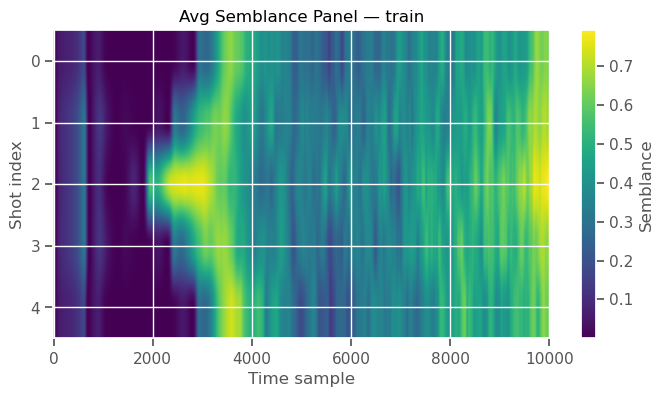

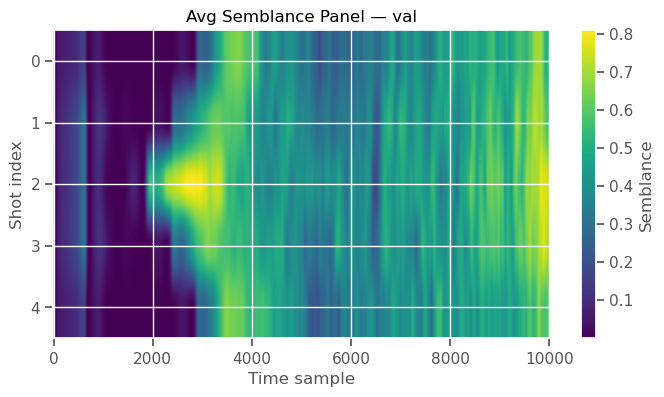

In [3]:
# Plot average semblance by split

for split, ids in [('train', train_ids), ('val', val_ids)]:
    # average semblance across 20 random samples
    sem_sum = None
    for sid in np.random.choice(ids, 20, replace=False):
        sem = compute_semblance_panel(load_gather(sid))
        sem_sum = sem if sem_sum is None else sem_sum + sem
    avg_sem = sem_sum / 20
    plt.figure(figsize=(8,4))
    plt.imshow(avg_sem, aspect='auto', cmap='viridis')
    plt.title(f'Avg Semblance Panel — {split}')
    plt.xlabel('Time sample'); plt.ylabel('Shot index')
    plt.colorbar(label='Semblance')
    plt.show()

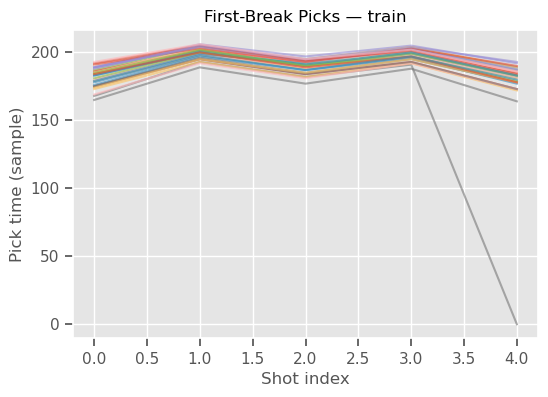

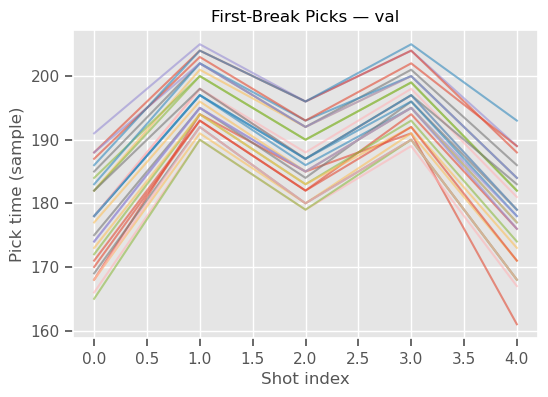

In [20]:
for split, ids in [('train', train_ids), ('val', val_ids)]:
    fig, ax = plt.subplots(figsize=(6,4))
    for sid in np.random.choice(ids, 30, replace=False):
        picks = pick_first_breaks_per_shot(load_gather(sid))
        ax.plot(picks, label=sid, alpha=0.6)
    ax.set_title(f'First‐Break Picks — {split}')
    ax.set_xlabel('Shot index'); ax.set_ylabel('Pick time (sample)')
    plt.show()


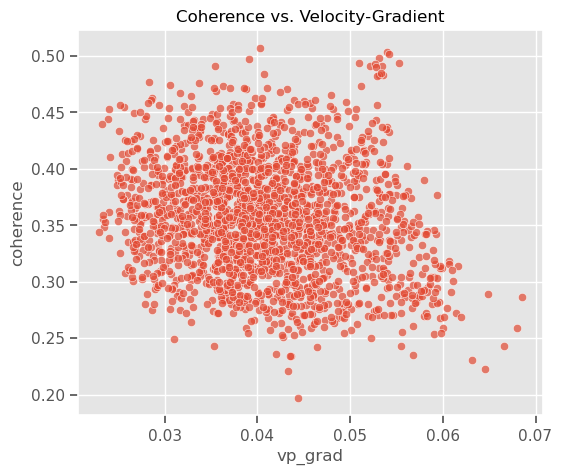

In [23]:
# Coherence vs Velocity Gradients

# Compute gradient‐mean of vp model
def mean_vp_gradient(vp):
    gx = sobel(vp, axis=0)
    gy = sobel(vp, axis=1)
    return np.sqrt(gx**2 + gy**2).mean()

rows = []
for _, row in df_feats.iterrows():
    sid = row.sample_id
    gather = load_gather(sid)
    sem = compute_semblance_panel(gather)
    coh = sem.mean()
    vp = np.load(f'../data/raw/train_data/{sid}/vp_model.npy')
    grad = mean_vp_gradient(vp)
    rows.append({'sample': sid, 'coherence': coh, 'vp_grad': grad})
df_coh = pd.DataFrame(rows)

plt.figure(figsize=(6,5))
sns.scatterplot(data=df_coh, x='vp_grad', y='coherence', alpha=0.7)
plt.title('Coherence vs. Velocity‐Gradient')
plt.show()
